<a href="https://colab.research.google.com/github/zubaeteee20210205109-droid/Trial/blob/main/A_Hybrid_CNN%E2%80%93EfficientNetB4_Framework_with_Squeeze_and_Excitation_Attention_for_Multi_Class_Skin_Lesion_Classification_on_the_PAD_UFES_20_Dataset.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import EfficientNetB4
from tensorflow.keras.applications.efficientnet import preprocess_input

from tensorflow.keras.layers import *
from tensorflow.keras.models import Model
from tensorflow.keras.callbacks import (
    EarlyStopping,
    ReduceLROnPlateau,
    ModelCheckpoint
)

from tensorflow.keras.optimizers import AdamW

from sklearn.utils.class_weight import compute_class_weight
import os
from sklearn.metrics import confusion_matrix

In [ ]:
train_path = "/content/drive/MyDrive/SkinCancer_Split/train"
test_path  = "/content/drive/MyDrive/SkinCancer_Split/test"

IMG_SIZE = 224
BATCH_SIZE = 32

In [ ]:
train_datagen = ImageDataGenerator(
    preprocessing_function=preprocess_input,
    rotation_range=30,
    zoom_range=0.25,
    horizontal_flip=True,
    width_shift_range=0.1,
    height_shift_range=0.1,
    brightness_range=[0.8,1.2]
)

test_datagen = ImageDataGenerator(
    preprocessing_function=preprocess_input
)

In [ ]:
train_generator = train_datagen.flow_from_directory(
    train_path,
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=True
)

test_generator = test_datagen.flow_from_directory(
    test_path,
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=False
)

NUM_CLASSES = train_generator.num_classes

print(train_generator.class_indices)

Found 1838 images belonging to 6 classes.
Found 460 images belonging to 6 classes.
{'ACK': 0, 'BCC': 1, 'MEL': 2, 'NEV': 3, 'SCC': 4, 'SEK': 5}


In [ ]:
classes = train_generator.classes

weights = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(classes),
    y=classes
)

class_weights = dict(enumerate(weights))

print(class_weights)

{0: np.float64(0.5245433789954338), 1: np.float64(0.4531558185404339), 2: np.float64(7.2936507936507935), 3: np.float64(1.570940170940171), 4: np.float64(2.002178649237473), 5: np.float64(1.6294326241134751)}


In [ ]:
input_layer = Input(shape=(224,224,3))
#CNN BRANCH
x = Conv2D(32,(3,3),activation='relu',padding='same')(input_layer)
x = BatchNormalization()(x)
x = Conv2D(32,(3,3),activation='relu')(x)
x = MaxPooling2D()(x)

x = Conv2D(64,(3,3),activation='relu',padding='same')(x)
x = BatchNormalization()(x)
x = Conv2D(64,(3,3),activation='relu')(x)
x = MaxPooling2D()(x)

x = Conv2D(128,(3,3),activation='relu',padding='same')(x)
x = BatchNormalization()(x)
x = Conv2D(128,(3,3),activation='relu')(x)
x = MaxPooling2D()(x)

x = Conv2D(256,(3,3),activation='relu')(x)
x = BatchNormalization()(x)
x = MaxPooling2D()(x)

cnn_features = GlobalAveragePooling2D()(x)
cnn_features = Dense(256,activation='relu')(cnn_features)

#EfficientNetB4 Backbone
base_model = EfficientNetB4(
    weights='imagenet',
    include_top=False,
    input_tensor=input_layer
)

base_model.trainable = True

for layer in base_model.layers[:-80]:
    layer.trainable = False

y = base_model.output

#SE Attention Block
def se_block(input_tensor, ratio=8):

    filters = input_tensor.shape[-1]

    se = GlobalAveragePooling2D()(input_tensor)

    se = Dense(filters//ratio,
               activation='relu')(se)

    se = Dense(filters,
               activation='sigmoid')(se)

    se = Reshape((1,1,filters))(se)

    return Multiply()([input_tensor,se])

#Attention Features
attention = se_block(y)

attention = GlobalAveragePooling2D()(attention)

#EfficientNet Branch
y = GlobalAveragePooling2D()(y)

y = Dense(512,activation='relu')(y)
y = BatchNormalization()(y)

y = Dense(256,activation='relu')(y)
y = Dropout(0.5)(y)

efficient_features = Dense(256,activation='relu')(y)

#Feature Fusion
combined = Concatenate()(
    [cnn_features,
     efficient_features,
     attention]
)

#Classification Head
z = Dense(512,activation='relu')(combined)
z = BatchNormalization()(z)

z = Dense(256,activation='relu')(z)
z = Dropout(0.5)(z)

z = Dense(128,activation='relu')(z)
z = Dropout(0.4)(z)

output = Dense(
    NUM_CLASSES,
    activation='softmax'
)(z)

model = Model(
    inputs=input_layer,
    outputs=output
)

model.summary()


71686520/71686520 ━━━━━━━━━━━━━━━━━━━━ 4s 0us/step


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ rescaling           │ (None, 224, 224,  │          0 │ input_layer[0][0] │
│ (Rescaling)         │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ normalization       │ (None, 224, 224,  │          7 │ rescaling[0][0]   │
│ (Normalization)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ rescaling_1         │ (None, 224, 224,  │          0 │ normalization[0]… │
│ (Rescaling)         │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_conv_pad       │ (None, 225, 225,  │          0 │ rescaling_1[0][0] │
│ (ZeroPadding2D)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_conv (Conv2D)  │ (None, 112, 112,  │      1,296 │ stem_conv_pad[0]… │
│                     │ 48)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_bn             │ (None, 112, 112,  │        192 │ stem_conv[0][0]   │
│ (BatchNormalizatio… │ 48)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_activation     │ (None, 112, 112,  │          0 │ stem_bn[0][0]     │
│ (Activation)        │ 48)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_dwconv      │ (None, 112, 112,  │        432 │ stem_activation[… │
│ (DepthwiseConv2D)   │ 48)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_bn          │ (None, 112, 112,  │        192 │ block1a_dwconv[0… │
│ (BatchNormalizatio… │ 48)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_activation  │ (None, 112, 112,  │          0 │ block1a_bn[0][0]  │
│ (Activation)        │ 48)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_squeeze  │ (None, 48)        │          0 │ block1a_activati… │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_reshape  │ (None, 1, 1, 48)  │          0 │ block1a_se_squee… │
│ (Reshape)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_reduce   │ (None, 1, 1, 12)  │        588 │ block1a_se_resha… │
│ (Conv2D)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_expand   │ (None, 1, 1, 48)  │        624 │ block1a_se_reduc… │
│ (Conv2D)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_excite   │ (None, 112, 112,  │          0 │ block1a_activati… │
│ (Multiply)          │ 48)               │            │ block1a_se_expan… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_project_co… │ (None, 112, 112,  │      1,152 │ block1a_se_excit

 Total params: 21,592,933 (82.37 MB)

 Trainable params: 13,114,950 (50.03 MB)

 Non-trainable params: 8,477,983 (32.34 MB)

In [ ]:
optimizer = AdamW(
    learning_rate=3e-4,
    weight_decay=1e-4
)

model.compile(
    optimizer=optimizer,
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

In [ ]:
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=8,
    restore_best_weights=True,
    verbose=1
)

reduce_lr = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.3,
    patience=3,
    verbose=1
)

checkpoint = ModelCheckpoint(
    "best_Hybrid_CNN_EfficientNetB4_SE_PADUFES20.keras",
    monitor='val_accuracy',
    save_best_only=True,
    mode='max',
    verbose=1
)

In [9]:
history = model.fit(
    train_generator,
    validation_data=test_generator,
    epochs=20,
    class_weight=class_weights,
    callbacks=[
        early_stop,
        reduce_lr,
        checkpoint
    ]
)

Epoch 1/20
58/58 ━━━━━━━━━━━━━━━━━━━━ 0s 27s/step - accuracy: 0.2568 - loss: 2.5143 
Epoch 1: val_accuracy improved from None to 0.34348, saving model to best_Hybrid_CNN_EfficientNetB4_SE_PADUFES20.keras

Epoch 1: finished saving model to best_Hybrid_CNN_EfficientNetB4_SE_PADUFES20.keras
58/58 ━━━━━━━━━━━━━━━━━━━━ 2027s 34s/step - accuracy: 0.2530 - loss: 2.3824 - val_accuracy: 0.3435 - val_loss: 1.7397 - learning_rate: 3.0000e-04
Epoch 2/20
58/58 ━━━━━━━━━━━━━━━━━━━━ 0s 24s/step - accuracy: 0.2752 - loss: 1.8520 
Epoch 2: val_accuracy did not improve from 0.34348
58/58 ━━━━━━━━━━━━━━━━━━━━ 1587s 27s/step - accuracy: 0.2786 - loss: 1.8848 - val_accuracy: 0.2674 - val_loss: 1.6907 - learning_rate: 3.0000e-04
Epoch 3/20
58/58 ━━━━━━━━━━━━━━━━━━━━ 0s 24s/step - accuracy: 0.3225 - loss: 1.6781 
Epoch 3: val_accuracy improved from 0.34348 to 0.43913, saving model to best_Hybrid_CNN_EfficientNetB4_SE_PADUFES20.keras

Epoch 3: finished saving model to best_Hybrid_CNN_EfficientNetB4_SE_PADUFES

In [22]:
loss, accuracy = model.evaluate(test_generator)

print("Test Loss :", round(loss,4))
print("Test Accuracy :", round(accuracy*100,2), "%")

15/15 ━━━━━━━━━━━━━━━━━━━━ 173s 11s/step - accuracy: 0.6783 - loss: 0.8695
Test Loss : 0.8695
Test Accuracy : 67.83 %


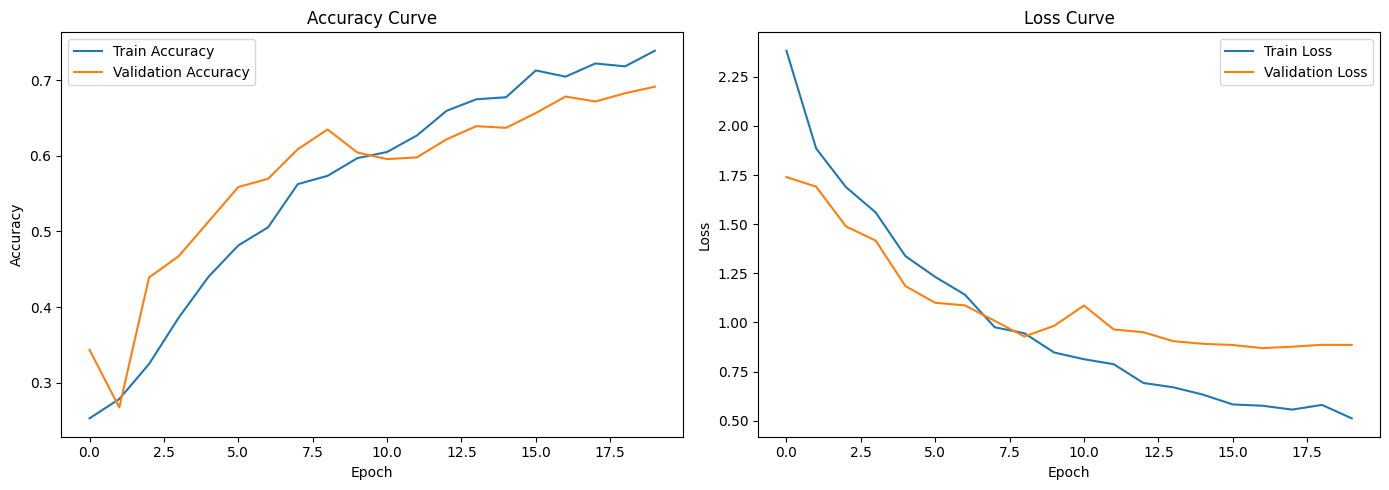

In [21]:
plt.figure(figsize=(14,5))

# Accuracy
plt.subplot(1,2,1)
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.title('Accuracy Curve')
plt.legend()

# Loss
plt.subplot(1,2,2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Loss Curve')
plt.legend()

plt.tight_layout()
plt.show()

In [23]:
test_generator.reset()

y_pred_prob = model.predict(test_generator)

y_pred = np.argmax(y_pred_prob, axis=1)

y_true = test_generator.classes

class_names = list(test_generator.class_indices.keys())

15/15 ━━━━━━━━━━━━━━━━━━━━ 157s 10s/step


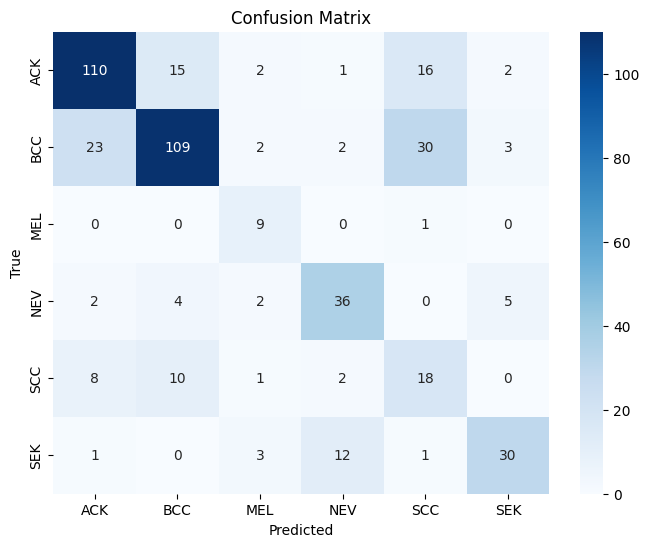

In [24]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(8,6))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=class_names,
    yticklabels=class_names
)

plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix')
plt.show()

In [25]:
from sklearn.metrics import classification_report

print(classification_report(
    y_true,
    y_pred,
    target_names=class_names
))

              precision    recall  f1-score   support

         ACK       0.76      0.75      0.76       146
         BCC       0.79      0.64      0.71       169
         MEL       0.47      0.90      0.62        10
         NEV       0.68      0.73      0.71        49
         SCC       0.27      0.46      0.34        39
         SEK       0.75      0.64      0.69        47

    accuracy                           0.68       460
   macro avg       0.62      0.69      0.64       460
weighted avg       0.72      0.68      0.69       460



In [26]:
from sklearn.metrics import precision_score
from sklearn.metrics import recall_score
from sklearn.metrics import f1_score

precision = precision_score(
    y_true,
    y_pred,
    average='weighted'
)

recall = recall_score(
    y_true,
    y_pred,
    average='weighted'
)

f1 = f1_score(
    y_true,
    y_pred,
    average='weighted'
)

print("Precision : {:.2f}%".format(precision*100))
print("Recall    : {:.2f}%".format(recall*100))
print("F1 Score  : {:.2f}%".format(f1*100))

Precision : 71.50%
Recall    : 67.83%
F1 Score  : 68.99%


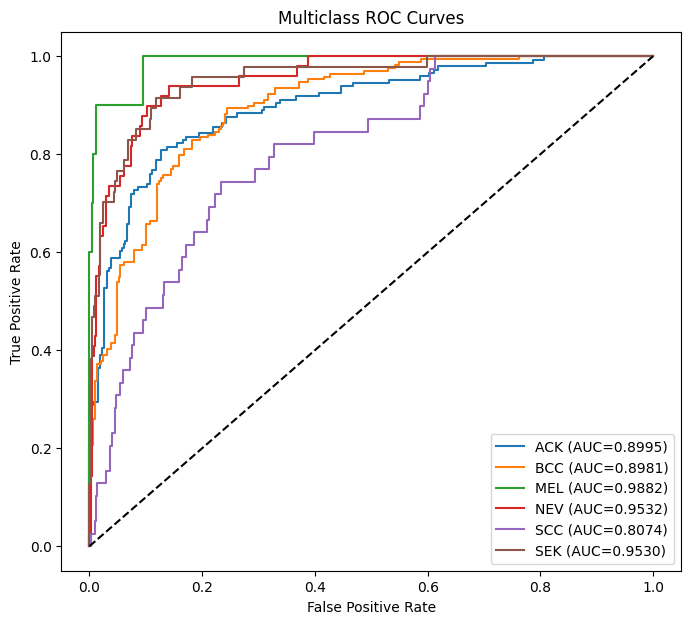

In [27]:
from sklearn.preprocessing import label_binarize
from sklearn.metrics import roc_curve, auc

n_classes = len(class_names)

y_true_bin = label_binarize(
    y_true,
    classes=np.arange(n_classes)
)

fpr = {}
tpr = {}
roc_auc = {}

plt.figure(figsize=(8,7))

for i in range(n_classes):

    fpr[i], tpr[i], _ = roc_curve(
        y_true_bin[:,i],
        y_pred_prob[:,i]
    )

    roc_auc[i] = auc(
        fpr[i],
        tpr[i]
    )

    plt.plot(
        fpr[i],
        tpr[i],
        label=f'{class_names[i]} (AUC={roc_auc[i]:.4f})'
    )

plt.plot([0,1],[0,1],'k--')

plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Multiclass ROC Curves')
plt.legend()
plt.show()

In [28]:
print("AUC Values")

for i in range(n_classes):
    print(
        class_names[i],
        ":",
        round(roc_auc[i],4)
    )

AUC Values
ACK : 0.8995
BCC : 0.8981
MEL : 0.9882
NEV : 0.9532
SCC : 0.8074
SEK : 0.953


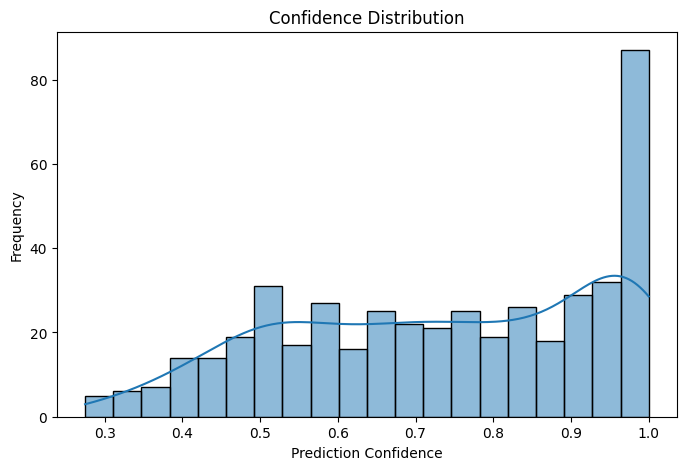

In [29]:
confidence = np.max(y_prob, axis=1)

plt.figure(figsize=(8,5))

sns.histplot(
    confidence,
    bins=20,
    kde=True
)

plt.xlabel("Prediction Confidence")
plt.ylabel("Frequency")

plt.title("Confidence Distribution")

plt.show()

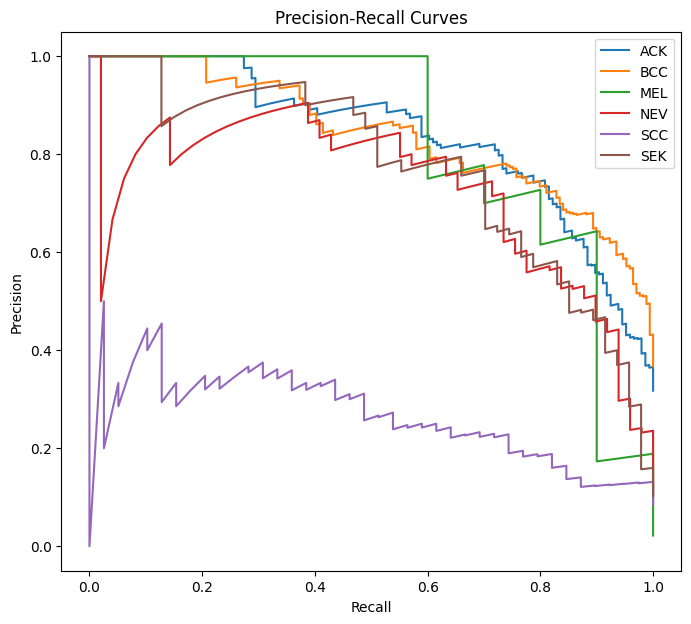

In [30]:
from sklearn.metrics import precision_recall_curve

plt.figure(figsize=(8,7))

for i in range(n_classes):

    precision_curve, recall_curve, _ = precision_recall_curve(
        y_true_bin[:,i],
        y_pred_prob[:,i]
    )

    plt.plot(
        recall_curve,
        precision_curve,
        label=class_names[i]
    )

plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curves")
plt.legend()
plt.show()